In [1]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Import and load the dataset
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
os.makedirs("figures", exist_ok=True)

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# check the data
df.info()
print(df.isna().sum().sum(),"missing values")
print(df.duplicated().sum(),"duplicate rows")


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
# finding the problem in TotalCharges
print((df["TotalCharges"].str.strip() == "").sum(),"empty values in TotalCharges")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df[df["TotalCharges"].isna()][["tenure","MonthlyCharges","TotalCharges"]]


11 empty values in TotalCharges


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [8]:
# clean the data
df["TotalCharges"] = df["TotalCharges"].fillna(0)                 # new customers → 0 charges
df = df.drop(columns="customerID")                                # ID is useless for prediction
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})                # target → 1/0
df["SeniorCitizen"] = df["SeniorCitizen"].map({1: "Yes", 0: "No"})  # match other Yes/No columns
df.dtypes

gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

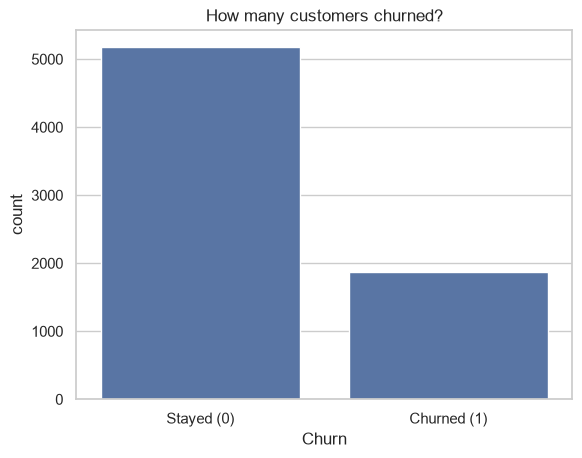

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [9]:
# class balance
ax = sns.countplot(x="Churn", data=df)
ax.set_xticks([0, 1], ["Stayed (0)", "Churned (1)"])
ax.set_title("How many customers churned?")
plt.savefig("figures/01_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()
df["Churn"].value_counts(normalize=True)

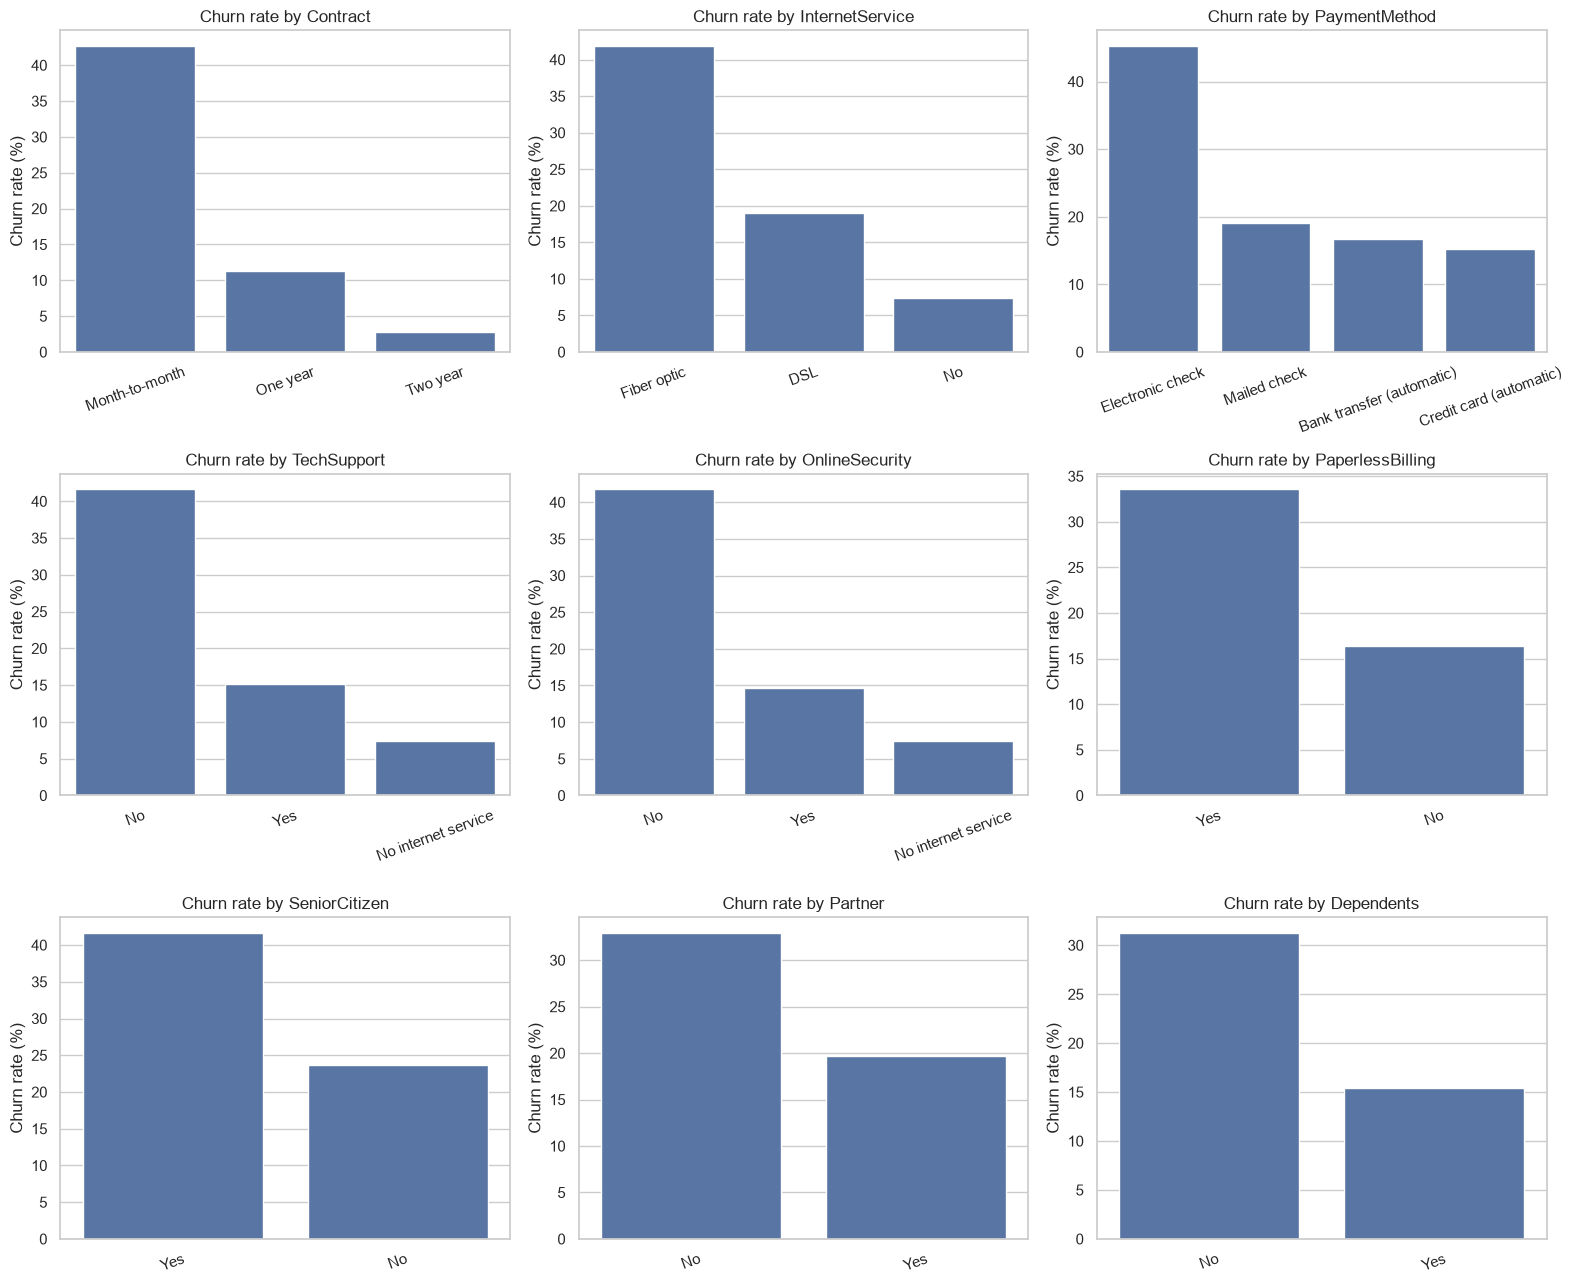

In [10]:
# churn rate by customer type
cat_cols = ["Contract", "InternetService", "PaymentMethod",
            "TechSupport", "OnlineSecurity", "PaperlessBilling",
            "SeniorCitizen", "Partner", "Dependents"]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, col in zip(axes.flat, cat_cols):
    rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("figures/02_churn_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

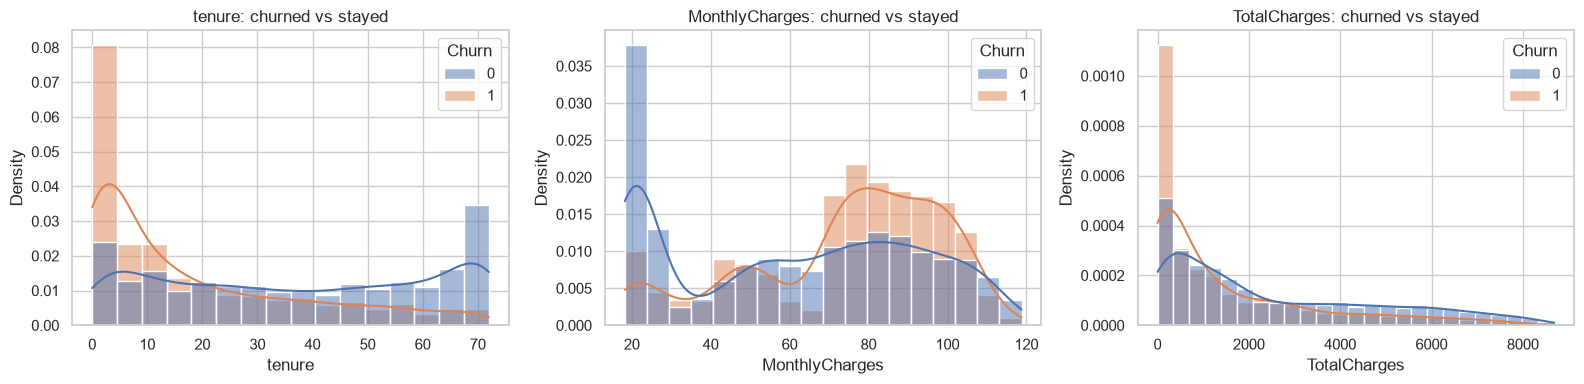

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,38.0,64.425,1679.525
1,10.0,79.650,703.550


In [11]:
# tenure and charges, churned vs stayed
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True,
                 stat="density", common_norm=False, ax=ax)
    ax.set_title(f"{col}: churned vs stayed")
plt.tight_layout()
plt.savefig("figures/03_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
df.groupby("Churn")[num_cols].median()

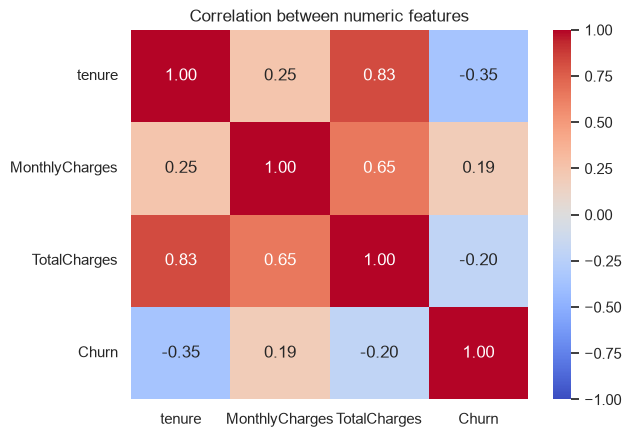

In [12]:
# correlation heatmap
corr = df[num_cols + ["Churn"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between numeric features")
plt.savefig("figures/04_correlation.png", dpi=150, bbox_inches="tight")
plt.show()